In [1]:
import numpy as np
import json
from data.dataset import LandmarksDataset, ToTensorWithSeg
from data.transforms import Scale
from models.hybridgnet_se_resnext_dual import HybridDual
from models.hybridgnet_se_resnext import Hybrid
from models.utils import load_config
from torchvision import transforms
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
import matplotlib.gridspec as gridspec

In [2]:
DATASET = '../Dataset/CAMUS/Landmarks_3_10'
NAME = 'CAMUS_atlas_seg_NN'

hyperparameters = json.load(open("../Training/%s/hyperparameters.json"%NAME))
config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Training/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = True

if config['use_dual']:
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
else:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])

print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])

model.eval()
    
images = np.loadtxt("%s/test.txt"%DATASET, dtype = str)
val_dataset = LandmarksDataset(images, "%s/images"%DATASET, "%s/landmarks"%DATASET, 
                               transform = transforms.Compose([Scale(config['inputsize']), ToTensorWithSeg()]))

Configuration
database_path : ../CAMUS/database_nifti
output_path : ../Dataset/CAMUS/Landmarks_3_10
scale_factor : 0.1
resolutions : ['full', 'half', 'quarter']
image_types : ['2CH', '4CH']
organs : ['1', '2', '3']
organ_names : ['LV Endo', 'LV Epi', 'LA']
inputsize : 512
flip_h : True
flip_v : False
rotate : True
transpose : False

Loading adjacency matrices ../Dataset/CAMUS/Landmarks_3_10/NonNaive/adj_full_block_diagonal.npy


/home/ngaggion/Documents/Mask2Graph/Repo/models/utils.py:14: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  sparse_tensor = torch.sparse.FloatTensor(i, v, torch.Size(shape))


Image Encoder filters [16, 32, 64, 128, 256, 256]
Bottleneck latents 64
Graph convolutional filters [32, 32, 24, 24, 16, 16, 8, 2]


Processing patient patient0108, chamber 2CH
ED Frame: 0, ES Frame: 18


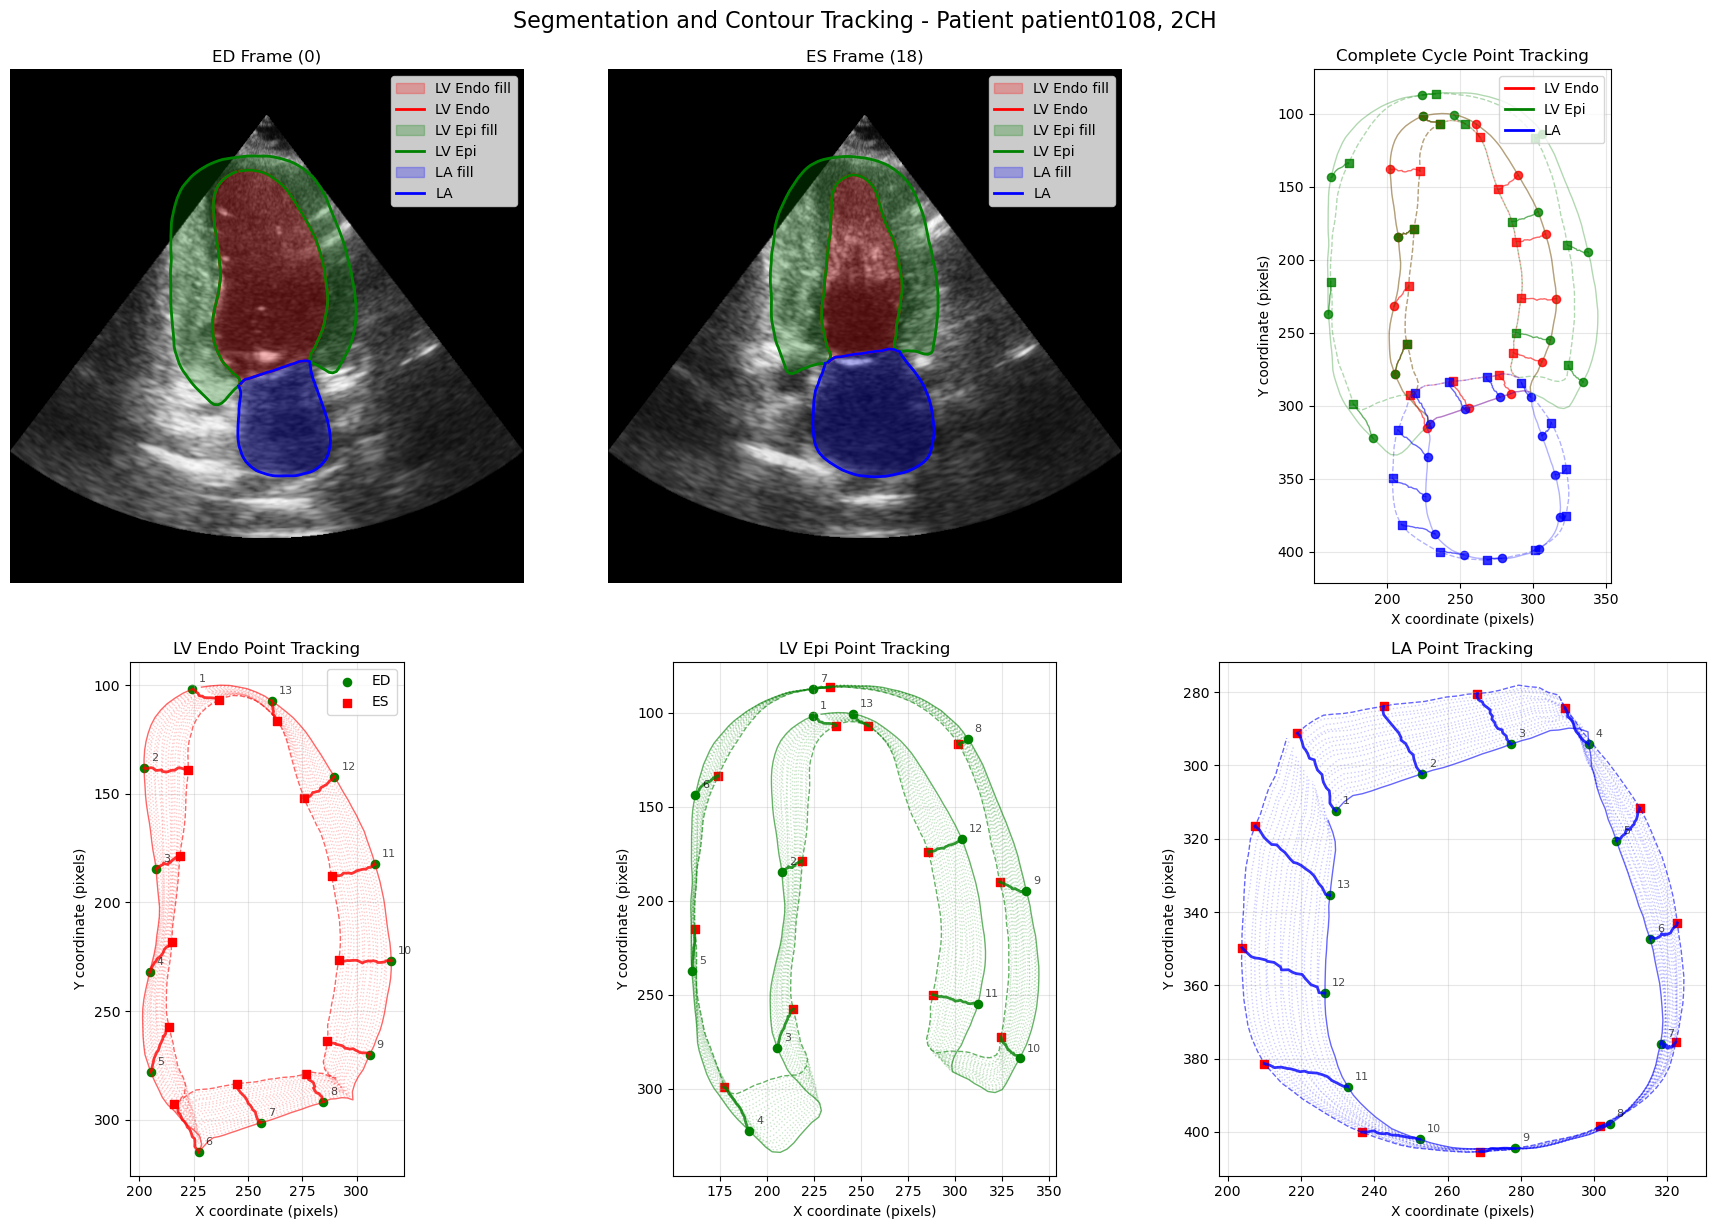


Processed patient patient0108, chamber 2CH
Total frames processed: 19
Extracted segmentations for 3 organs
  LV Endo: 13 point trajectories across 19 frames
  LV Epi: 13 point trajectories across 19 frames
  LA: 13 point trajectories across 19 frames
--------------------------------------------------
Processing patient patient0108, chamber 4CH
ED Frame: 0, ES Frame: 25


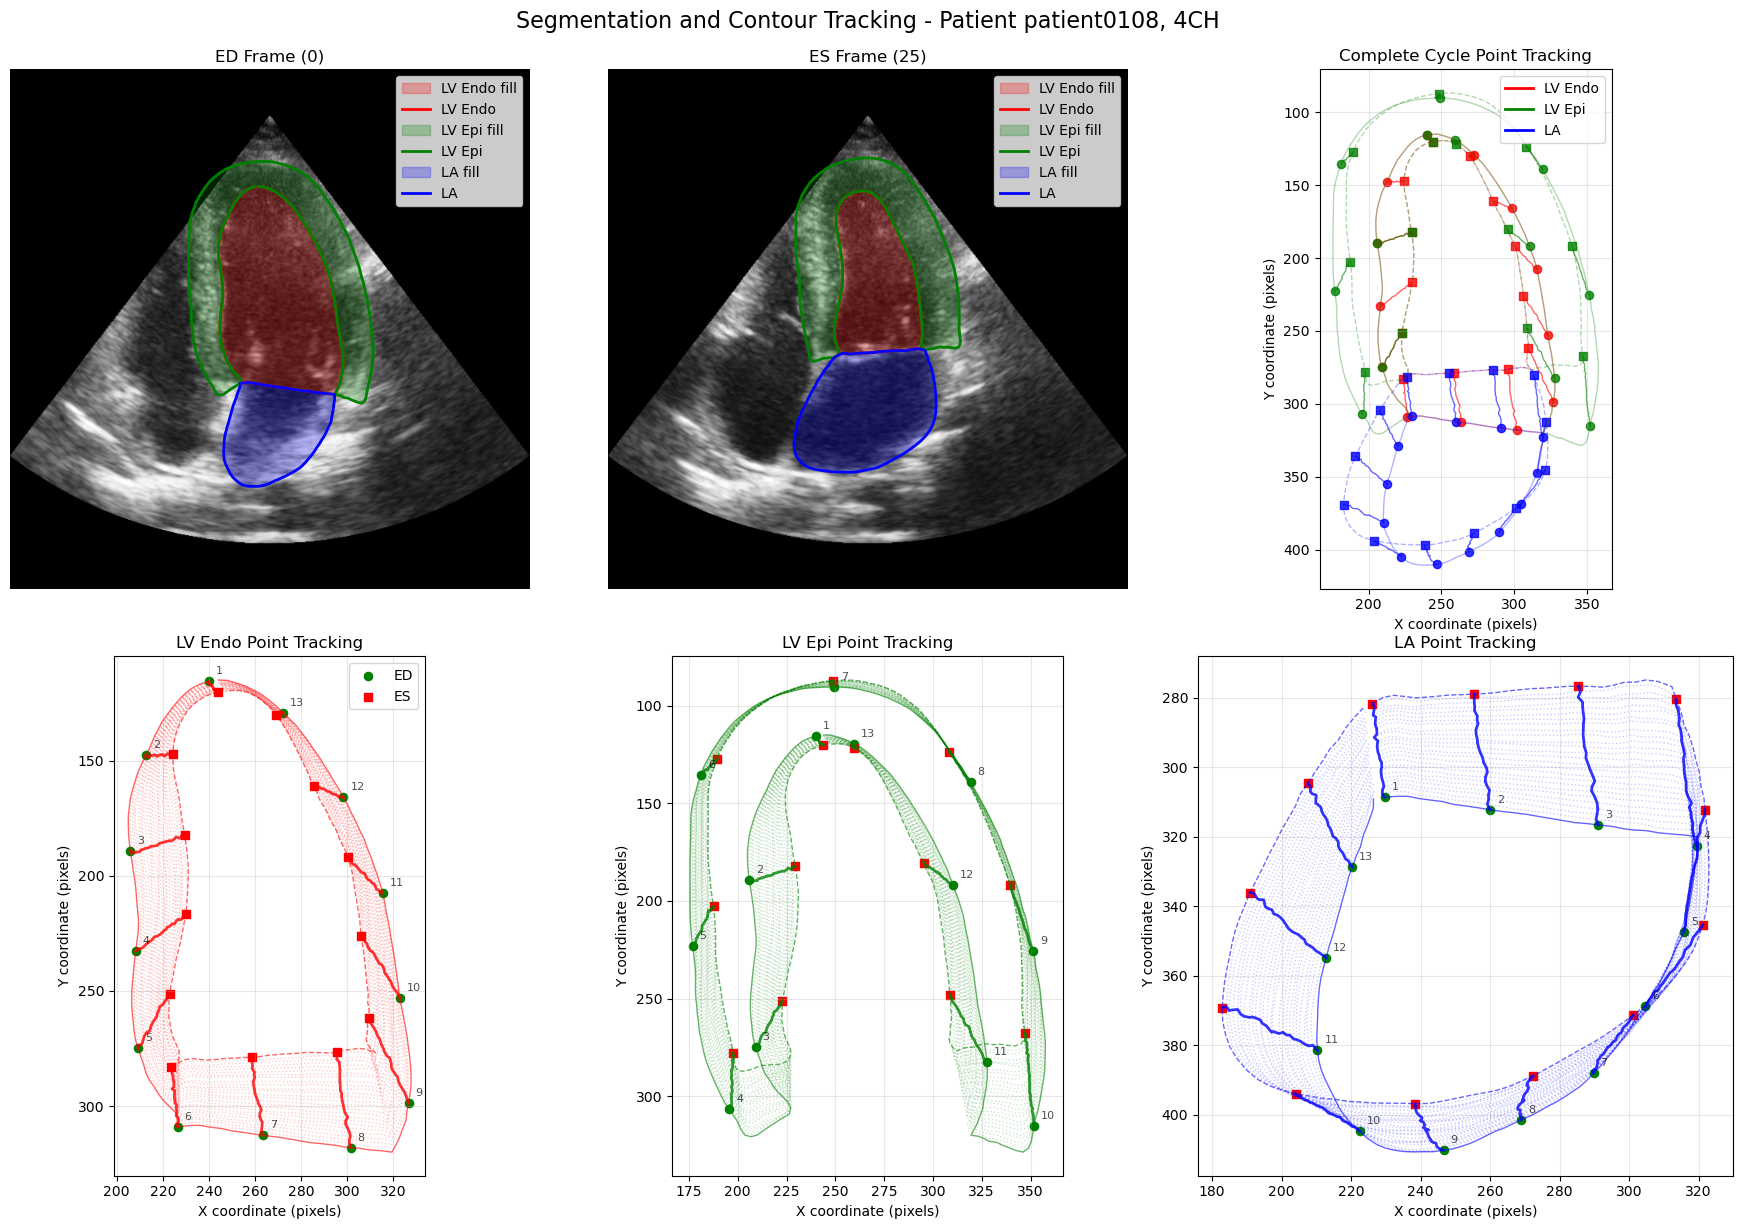


Processed patient patient0108, chamber 4CH
Total frames processed: 26
Extracted segmentations for 3 organs
  LV Endo: 13 point trajectories across 26 frames
  LV Epi: 13 point trajectories across 26 frames
  LA: 13 point trajectories across 26 frames
--------------------------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import json
from collections import defaultdict

def readInfo(patient, chamber):
    """Read patient information from config file"""
    info = database_path + f"/{patient}/Info_{chamber}.cfg"
    with open(info, 'r') as f:
        lines = f.readlines()
    
    info_dict = {}
    for line in lines:
        if line.strip() and not line.startswith("#"):
            key, value = line.split(":")
            info_dict[key.strip()] = value.strip()
    return info_dict

def natural_sort_key(s):
    """Sort strings with numbers correctly (1, 2, 3, ..., 10, 11)"""
    import re
    return [int(text) if text.isdigit() else text.lower() 
            for text in re.split(r'(\d+)', s[0])]

# Configuration
database_path = "../CAMUS/database_nifti"
organ_id = np.load("%s/NonNaive/adj_full_organ_id.npy" % DATASET)[:,0]
organs = config['organs']
organ_names = config['organ_names']
organ_dict = {organs[i]: organ_names[i] for i in range(len(organ_names))}

with open(f"{DATASET}/NonNaive/organ_order_full.json", "r") as f:
    circ_organ_order = json.load(f)

# Define colors for visualization
organ_colors = {
    'LV Endo': 'red',
    'LV Epi': 'green', 
    'LA': 'blue'
}

# Group images by patient and chamber
patients = [image.split("/")[0] for image in images]
chambers = [image.split("/")[1] for image in images]
frames = [image.split("/")[2] for image in images]

patient_chamber_frames = defaultdict(lambda: defaultdict(list))
for i, image in enumerate(images):
    patient = patients[i]
    chamber = chambers[i]
    frame = frames[i]
    patient_chamber_frames[patient][chamber].append((frame, i))

# Process each patient and chamber
for patient in patient_chamber_frames:
    for chamber in patient_chamber_frames[patient]:
        print(f"Processing patient {patient}, chamber {chamber}")
        
        # Get patient info
        info_dict = readInfo(patient, chamber)
        ED_Frame = str(int(info_dict['ED']) - 1)
        ES_Frame = str(int(info_dict['ES']) - 1)
        
        print(f"ED Frame: {ED_Frame}, ES Frame: {ES_Frame}")
        
        # Sort frames and find ED/ES indices
        frames_indices = sorted(patient_chamber_frames[patient][chamber], key=natural_sort_key)
        
        frame_name_to_position = {}
        for i, (frame_name, _) in enumerate(frames_indices):
            clean_frame_name = frame_name.replace('.png', '')
            frame_name_to_position[clean_frame_name] = i
        
        ED_idx = frame_name_to_position.get(ED_Frame, 0)
        ES_idx = frame_name_to_position.get(ES_Frame, len(frames_indices)//2)
        
        # Process ALL frames for complete cycle tracking
        all_predictions = {}
        all_images = []
        frame_names = []
        
        for frame_idx, (frame, dataset_idx) in enumerate(frames_indices):
            frame_names.append(frame)
            
            # Get the sample from dataset
            sample = val_dataset[dataset_idx]
            
            # Store the raw image
            raw_image = sample['image'].cpu().detach().numpy().squeeze()
            all_images.append(raw_image)
            
            # Run the model to get predictions
            output = model(sample['raster'].unsqueeze(0).to(config['device']))[0]
            
            # Process landmarks for each organ
            for organ in organs:
                idx_organ = circ_organ_order[organ]
                organ_name = organ_dict[str(int(organ))]
                
                if organ_name not in all_predictions:
                    all_predictions[organ_name] = []
                
                # Scale to image dimensions
                pred_organ = output[0, idx_organ].cpu().detach().numpy() * 512
                all_predictions[organ_name].append(pred_organ)
        
        # Get ED and ES specific data
        ed_image = all_images[ED_idx]
        es_image = all_images[ES_idx]
        ed_predictions = {organ: contours[ED_idx] for organ, contours in all_predictions.items()}
        es_predictions = {organ: contours[ES_idx] for organ, contours in all_predictions.items()}
        
        # Calculate complete cycle point tracking
        complete_cycle_tracking = {}
        for organ_name in all_predictions.keys():
            contours = all_predictions[organ_name]
            
            # Sample points for tracking (every nth point to avoid clutter)
            n = max(1, len(contours[0]) // 12)  # About 12 tracking points
            sample_indices = np.arange(0, len(contours[0]), n)
            
            # Track each point across all frames
            point_trajectories = []
            for idx in sample_indices:
                trajectory = []
                for frame_contour in contours:
                    if idx < len(frame_contour):
                        trajectory.append(frame_contour[idx])
                
                if len(trajectory) == len(contours):  # Only include complete trajectories
                    point_trajectories.append(np.array(trajectory))
            
            complete_cycle_tracking[organ_name] = point_trajectories
        
        # Create visualization with 2 rows, 3 columns
        fig = plt.figure(figsize=(18, 12))
        gs = gridspec.GridSpec(2, 3, figure=fig)
        
        # TOP ROW
        # Top Left: ED frame with contours
        ax_ed = fig.add_subplot(gs[0, 0])
        ax_ed.imshow(ed_image, cmap='gray')
        ax_ed.set_title(f"ED Frame ({ED_Frame})")
        
        for organ_name, color in organ_colors.items():
            if organ_name in ed_predictions:
                contour = ed_predictions[organ_name]
                # Fill the contour softly
                ax_ed.fill(contour[:, 0], contour[:, 1], color=color, alpha=0.25, label=f'{organ_name} fill')
                # Draw the contour outline
                ax_ed.plot(contour[:, 0], contour[:, 1], color=color, linewidth=2, label=organ_name)
        
        ax_ed.legend(loc='upper right', fontsize=10)
        ax_ed.axis('off')
        
        # Top Middle: ES frame with contours
        ax_es = fig.add_subplot(gs[0, 1])
        ax_es.imshow(es_image, cmap='gray')
        ax_es.set_title(f"ES Frame ({ES_Frame})")
        
        for organ_name, color in organ_colors.items():
            if organ_name in es_predictions:
                contour = es_predictions[organ_name]
                # Fill the contour softly
                ax_es.fill(contour[:, 0], contour[:, 1], color=color, alpha=0.25, label=f'{organ_name} fill')
                # Draw the contour outline
                ax_es.plot(contour[:, 0], contour[:, 1], color=color, linewidth=2, label=organ_name)
        
        ax_es.legend(loc='upper right', fontsize=10)
        ax_es.axis('off')
        
        # Top Right: Complete cycle tracking
        ax_complete = fig.add_subplot(gs[0, 2])
        ax_complete.set_title("Complete Cycle Point Tracking")
        
        for organ_name, color in organ_colors.items():
            if organ_name in complete_cycle_tracking:
                trajectories = complete_cycle_tracking[organ_name]
                
                # Plot ED and ES contours as reference
                if organ_name in ed_predictions:
                    ed_contour = ed_predictions[organ_name]
                    es_contour = es_predictions[organ_name]
                    
                    ax_complete.plot(ed_contour[:, 0], ed_contour[:, 1], 
                                   color=color, linestyle='-', alpha=0.3, linewidth=1)
                    ax_complete.plot(es_contour[:, 0], es_contour[:, 1], 
                                   color=color, linestyle='--', alpha=0.3, linewidth=1)
                
                # Plot point trajectories
                for trajectory in trajectories:
                    ax_complete.plot(trajectory[:, 0], trajectory[:, 1], 
                                   color=color, alpha=0.6, linewidth=1)
                    
                    # Mark start and end points
                    ax_complete.scatter(trajectory[0, 0], trajectory[0, 1], 
                                      color=color, s=35, marker='o', alpha=0.8)
                    ax_complete.scatter(trajectory[-1, 0], trajectory[-1, 1], 
                                      color=color, s=35, marker='s', alpha=0.8)
        
        ax_complete.set_aspect('equal')
        ax_complete.grid(True, alpha=0.3)
        ax_complete.set_xlabel('X coordinate (pixels)')
        ax_complete.set_ylabel('Y coordinate (pixels)')
        # invert y-axis to match image coordinates
        ax_complete.invert_yaxis()
        
        # Add legend for complete cycle
        from matplotlib.lines import Line2D
        legend_elements = []
        for organ_name, color in organ_colors.items():
            if organ_name in complete_cycle_tracking:
                legend_elements.append(Line2D([0], [0], color=color, lw=2, label=organ_name))
        ax_complete.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # BOTTOM ROW: Individual organ tracking
        organ_list = list(organ_colors.keys())
        for i, organ_name in enumerate(organ_list[:3]):  # Limit to 3 organs
            ax_organ = fig.add_subplot(gs[1, i])
            
            if organ_name in complete_cycle_tracking:
                color = organ_colors[organ_name]
                trajectories = complete_cycle_tracking[organ_name]
                
                # Plot all contours lightly
                for frame_idx, contour in enumerate(all_predictions[organ_name]):
                    alpha = 0.6 if frame_idx in [ED_idx, ES_idx] else 0.2
                    linestyle = '-' if frame_idx == ED_idx else ('--' if frame_idx == ES_idx else ':')
                    ax_organ.plot(contour[:, 0], contour[:, 1], 
                                color=color, alpha=alpha, linestyle=linestyle, linewidth=1)
                
                # Plot point trajectories with more detail
                for traj_idx, trajectory in enumerate(trajectories):
                    ax_organ.plot(trajectory[:, 0], trajectory[:, 1], 
                                color=color, alpha=0.8, linewidth=2)
                    
                    # Mark points at different phases
                    ax_organ.scatter(trajectory[ED_idx, 0], trajectory[ED_idx, 1], 
                                   color='green', s=35, marker='o', label='ED' if traj_idx == 0 else "")
                    ax_organ.scatter(trajectory[ES_idx, 0], trajectory[ES_idx, 1], 
                                   color='red', s=35, marker='s', label='ES' if traj_idx == 0 else "")
                    
                    # Number the tracking points
                    ax_organ.annotate(f'{traj_idx+1}', 
                                    (trajectory[0, 0], trajectory[0, 1]), 
                                    xytext=(5, 5), textcoords='offset points',
                                    fontsize=8, alpha=0.7)
                
                ax_organ.set_title(f'{organ_name} Point Tracking')
                ax_organ.set_aspect('equal')
                ax_organ.grid(True, alpha=0.3)
                ax_organ.set_xlabel('X coordinate (pixels)')
                ax_organ.set_ylabel('Y coordinate (pixels)')
                ax_organ.invert_yaxis()
                
                if i == 0:  # Only show legend on first plot
                    ax_organ.legend(loc='upper right', fontsize=10)
            else:
                ax_organ.text(0.5, 0.5, f'No data for {organ_name}', 
                            ha='center', va='center', transform=ax_organ.transAxes)
                ax_organ.set_title(f'{organ_name} - No Data')
        
        plt.tight_layout()
        plt.suptitle(f'Segmentation and Contour Tracking - Patient {patient}, {chamber}', 
                    fontsize=16, y=1.02)
        
        plt.savefig(f'seg_complete_cardiac_analysis_{patient}_{chamber}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print summary
        print(f"\nProcessed patient {patient}, chamber {chamber}")
        print(f"Total frames processed: {len(frames_indices)}")
        print(f"Extracted segmentations for {len(all_predictions)} organs")
        for organ_name in complete_cycle_tracking:
            n_trajectories = len(complete_cycle_tracking[organ_name])
            n_frames = len(all_predictions[organ_name])
            print(f"  {organ_name}: {n_trajectories} point trajectories across {n_frames} frames")
        print("-" * 50)
        
    break  # Process only one patient